In [1]:
import sys
print(sys.executable)

C:\Anaconda3\envs\myproject312\python.exe


In [2]:
!python --version


Python 3.12.15


In [3]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [4]:
import tensorflow as tf
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [5]:
x_train.shape

(60000, 28, 28)

In [6]:
x_test.shape

(10000, 28, 28)

In [7]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)

In [8]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [9]:
x_train /= 255
x_test /= 255

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
model = Sequential()
model.add(Conv2D(28, kernel_size=(3,3), input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation=tf.nn.relu))
model.add(Dropout(0.2))
model.add(Dense(10,activation=tf.nn.softmax))

C:\Anaconda3\envs\myproject312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
#https://keras.io/api/optimizers/
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x=x_train,y=y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9370 - loss: 0.2089
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9736 - loss: 0.0835
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9815 - loss: 0.0580
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9860 - loss: 0.0435
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9885 - loss: 0.0354
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9901 - loss: 0.0304
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9914 - loss: 0.0250
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9925 - loss: 0.0217
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9935 - loss: 0.0195
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9941 - loss: 0.0173


In [12]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9858 - loss: 0.0613


[0.06130444258451462, 0.98580002784729]

In [15]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   --------------- ------------------------ 3.7/9.3 MB 21.8 MB/s eta 0:00:01
   --------------- ------------------------ 3.7/9.3 MB 21.8 MB/s eta 0:00:01
   --------------- ------------------------ 3.7/9.3 MB 21.8 MB/s eta 0:00:01
   --------------- ------------------------ 3.7/9.3 MB 21.8 MB/s eta 0:00:01
   --------------------- ------------------ 5.0/9.3 MB 5.0 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.3 MB 6.8 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 7.1 MB/s  0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 28.5 MB/s  0:00:00

   ---------------------------------------- 0/6 [pyparsing]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
6


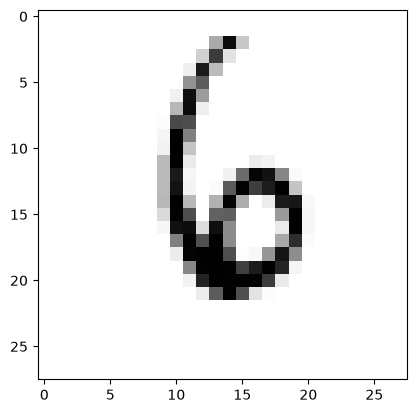

In [16]:
import matplotlib.pyplot as plt
image_index = 6900
plt.imshow(x_test[image_index].reshape(28, 28),cmap='Greys')
predict = x_test[image_index].reshape(28,28)
pred = model.predict(x_test[image_index].reshape(1, 28, 28, 1))
print(pred.argmax())

In [18]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 3.4 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.3 MB 4.2 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.3 MB 4.6 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.3 MB 5.1 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.3 MB 5.6 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.3 MB 5.7 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 5.8 MB/s  0:00:01
   ---------------------------------------- 0.0/36.7 MB ? eta -:--:--
   - -------------------------------------- 1.0/36.7 MB 5.0 MB/s eta 0:00:08
   -- ------------------------------------- 2.4/36.7 MB 5.6 MB/s eta 0:00:07
   --- ------------------------------------ 3.4/36.7 MB 5.8 MB/s eta 0:00:06
   ---- ----------------------------------- 4.2/36.7 MB 5.0 MB/s eta 0:00:07
   ----- ---------------

In [32]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV


In [34]:
!pip install seaborn
import seaborn as sns

  Using cached tzdata-2026.5-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.7 MB 5.6 MB/s eta 0:00:02
   ------ --------------------------------- 1.6/9.7 MB 4.0 MB/s eta 0:00:03
   --------- ------------------------------ 2.4/9.7 MB 4.1 MB/s eta 0:00:02
   ----------- ---------------------------- 2.9/9.7 MB 3.9 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.7 MB 3.7 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.7 MB 3.6 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.7 MB 3.6 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.7 MB 3.6 MB/s eta 0:00:02
   ---------------------------- ----------- 6.8/9.7 MB 3.7 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.7 MB 3.9 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.7 MB 4.0 MB/s eta 0:00:01
   ------------------------

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.99      0.99      0.99      1010
           4       0.98      0.99      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.98      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


Confusion Matrix:
[[ 972    0    2    0    2    0    1    2    1    0]
 [   0 1126    3    0    0    0    1    2    3    0]
 [   1    3 1015    1    1    0    2    7    2    0]

<Axes: >

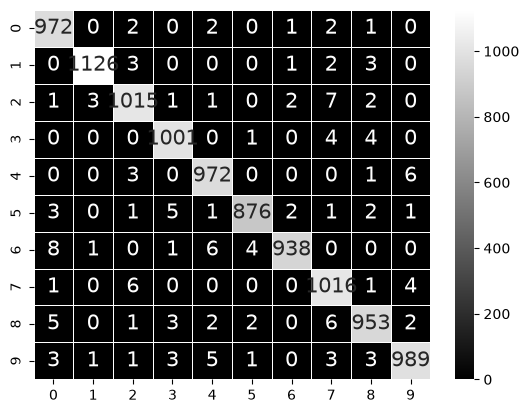

In [36]:

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions on the test set
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Optional: also print confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_classes))
con_mat=confusion_matrix(y_test,y_pred_classes)
sns.heatmap(con_mat,annot=True,annot_kws={'size':15},linewidth=0.5,fmt="d",cmap="gray")